<a href="https://colab.research.google.com/github/hemantachary/GroupDNA/blob/main/GroupDNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from datetime import datetime, timedelta

with open('/content/hostel_bois.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

print("Total lines:", len(lines))

Total lines: 3178


In [ ]:
line = "01/04/24, 01:17 - Rahul: scene fix"

timestamp, rest = line.split(" - ", 1)
sender, message = rest.split(": ", 1)

print(timestamp)
print(sender)
print(message)

01/04/24, 01:17
Rahul
scene fix


In [ ]:
import numpy as np
from datetime import datetime, timedelta

# Read the WhatsApp chat file
with open('/content/hostel_bois.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Lists and counters
messages = []
system_messages = []

media_count = 0
deleted_count = 0

current_message = None


# Go through every line
for raw_line in lines:

    line = raw_line.rstrip('\n')

    # Check whether this line looks like a new WhatsApp entry
    if " - " in line:

        timestamp_text, rest = line.split(" - ", 1)

        # Try to convert the timestamp into a datetime object
        try:
            timestamp = datetime.strptime(
                timestamp_text,
                "%d/%m/%y, %H:%M"
            )

        except ValueError:

            # If it isn't a valid timestamp,
            # treat it as continuation of previous message
            if current_message is not None:
                current_message["text"] += "\n" + line

            continue


        # Save the previous message before starting a new one
        if current_message is not None:
            messages.append(current_message)
            current_message = None


        # User message
        if ": " in rest:

            sender, text = rest.split(": ", 1)

            # Check message type
            if text == "<Media omitted>":
                message_type = "media"
                media_count += 1

            elif text == "This message was deleted":
                message_type = "deleted"
                deleted_count += 1

            else:
                message_type = "message"


            current_message = {
                "timestamp": timestamp,
                "sender": sender,
                "text": text,
                "type": message_type
            }


        # System message
        else:

            system_messages.append({
                "timestamp": timestamp,
                "text": rest
            })


    # Continuation of a previous message
    else:

        if current_message is not None:
            current_message["text"] += "\n" + line


# Save the final message
if current_message is not None:
    messages.append(current_message)


print("Parser finished!")
print("Real messages:", len(messages))
print("System messages:", len(system_messages))
print("Media messages:", media_count)
print("Deleted messages:", deleted_count)

Parser finished!
Real messages: 3174
System messages: 4
Media messages: 32
Deleted messages: 15


In [ ]:
print("\nFirst 5 messages:\n")

for message in messages[:5]:
    print(message)



First 5 messages:

{'timestamp': datetime.datetime(2024, 4, 1, 1, 17), 'sender': 'Rahul', 'text': 'scene fix', 'type': 'message'}
{'timestamp': datetime.datetime(2024, 4, 1, 1, 17), 'sender': 'Rahul', 'text': 'haan', 'type': 'message'}
{'timestamp': datetime.datetime(2024, 4, 1, 1, 18), 'sender': 'Rahul', 'text': 'kya scene', 'type': 'message'}
{'timestamp': datetime.datetime(2024, 4, 1, 2, 13), 'sender': 'Rahul', 'text': 'abhi free hai?', 'type': 'message'}
{'timestamp': datetime.datetime(2024, 4, 1, 2, 13), 'sender': 'Rahul', 'text': 'abey', 'type': 'message'}


In [ ]:
participants = [] #no of partici...

for message in messages:
    sender = message["sender"]

    if sender not in participants:
        participants.append(sender)

print("Participants:", participants)
print("Number of participants:", len(participants))

Participants: ['Rahul', 'Priya', 'Karan', 'Neha', 'Aman', 'Vikas']
Number of participants: 6


In [ ]:
# Count messages sent by each participant
message_counts = {}

for person in participants:
    message_counts[person] = 0

for message in messages:
    sender = message["sender"]
    message_counts[sender] += 1

print("\nMessage counts:")

for person in participants:
    print(person, ":", message_counts[person])


Message counts:
Rahul : 953
Priya : 718
Karan : 354
Neha : 635
Aman : 490
Vikas : 24


In [ ]:
total_messages = len(messages)

print("\nMessage percentages:")

for person in participants:

    count = message_counts[person]
    percentage = (count / total_messages) * 100

    print(
        person,
        ":",
        count,
        "messages |",
        round(percentage, 2),
        "%"
    )


Message percentages:
Rahul : 953 messages | 30.03 %
Priya : 718 messages | 22.62 %
Karan : 354 messages | 11.15 %
Neha : 635 messages | 20.01 %
Aman : 490 messages | 15.44 %
Vikas : 24 messages | 0.76 %


In [ ]:
# Create detailed statistics for each participant

person_stats = {}

for person in participants:

    person_stats[person] = {
        "messages": 0,
        "media": 0,
        "deleted": 0,
        "first_message": None,
        "last_message": None
    }


# Go through every message
for message in messages:

    person = message["sender"]

    # Total messages
    person_stats[person]["messages"] += 1

    # Media messages
    if message["type"] == "media":
        person_stats[person]["media"] += 1

    # Deleted messages
    if message["type"] == "deleted":
        person_stats[person]["deleted"] += 1

    # First message
    if person_stats[person]["first_message"] is None:
        person_stats[person]["first_message"] = message["timestamp"]

    # Last message
    person_stats[person]["last_message"] = message["timestamp"]


# Display the results
print("\nPERSON STATISTICS")
print("-----------------")

for person in participants:

    stats = person_stats[person]

    print("\n", person)
    print("Messages:", stats["messages"])
    print("Media:", stats["media"])
    print("Deleted:", stats["deleted"])
    print("First message:", stats["first_message"])
    print("Last message:", stats["last_message"])


PERSON STATISTICS
-----------------

 Rahul
Messages: 953
Media: 7
Deleted: 6
First message: 2024-04-01 01:17:00
Last message: 2024-05-30 17:04:00

 Priya
Messages: 718
Media: 4
Deleted: 2
First message: 2024-04-01 07:46:00
Last message: 2024-05-30 19:28:00

 Karan
Messages: 354
Media: 7
Deleted: 2
First message: 2024-04-01 12:39:00
Last message: 2024-05-30 21:30:00

 Neha
Messages: 635
Media: 8
Deleted: 3
First message: 2024-04-01 14:38:00
Last message: 2024-05-30 16:37:00

 Aman
Messages: 490
Media: 4
Deleted: 2
First message: 2024-04-01 20:12:00
Last message: 2024-05-30 23:31:00

 Vikas
Messages: 24
Media: 2
Deleted: 0
First message: 2024-04-05 19:06:00
Last message: 2024-05-27 08:55:00


In [ ]:
# Count messages for each date

date_counts = {}

for message in messages:

    date = message["timestamp"].date()

    if date not in date_counts:
        date_counts[date] = 0

    date_counts[date] += 1


# Find the busiest date
busiest_date = None
busiest_date_count = 0

for date in date_counts:

    if date_counts[date] > busiest_date_count:
        busiest_date = date
        busiest_date_count = date_counts[date]


print("BUSIEST DAY")
print("-----------")
print("Date:", busiest_date)
print("Messages:", busiest_date_count)

BUSIEST DAY
-----------
Date: 2024-05-04
Messages: 76


In [ ]:
# Count messages for each hour

hour_counts = np.zeros(24, dtype=int)

for message in messages:

    hour = message["timestamp"].hour

    hour_counts[hour] += 1


# Find the busiest hour
busiest_hour = np.argmax(hour_counts)

print("\nBUSIEST HOUR")
print("------------")
print("Hour:", busiest_hour)
print("Messages:", hour_counts[busiest_hour])


BUSIEST HOUR
------------
Hour: 18
Messages: 248


In [ ]:
# Convert the busiest hour into a readable format

if busiest_hour == 0:
    hour_text = "12 AM"
elif busiest_hour < 12:
    hour_text = str(busiest_hour) + " AM"
elif busiest_hour == 12:
    hour_text = "12 PM"
else:
    hour_text = str(busiest_hour - 12) + " PM"


print("\nBusiest hour:", hour_text)


Busiest hour: 6 PM


In [ ]:
# Create a fresh 6 x 24 matrix
activity_matrix = np.zeros(
    (len(participants), 24),
    dtype=int
)

# Fill the matrix ONCE
for message in messages:
    person = message["sender"]
    hour = message["timestamp"].hour
    person_index = participants.index(person)
    activity_matrix[person_index, hour] += 1

# Verify
matrix_total = np.sum(activity_matrix)

print("Messages from matrix:", matrix_total)
print("Messages from parser:", len(messages))

Messages from matrix: 3174
Messages from parser: 3174


In [ ]:
print("\nMOST ACTIVE HOUR PER PERSON")
print("---------------------------")

for i in range(len(participants)):

    person = participants[i]

    most_active_hour = np.argmax(activity_matrix[i])
    message_count = activity_matrix[i, most_active_hour]

    print(
        person,
        "→",
        most_active_hour,
        "hour,",
        message_count,
        "messages"
    )


MOST ACTIVE HOUR PER PERSON
---------------------------
Rahul → 18 hour, 105 messages
Priya → 9 hour, 65 messages
Karan → 12 hour, 37 messages
Neha → 18 hour, 62 messages
Aman → 4 hour, 88 messages
Vikas → 8 hour, 3 messages


In [ ]:
activity_matrix = np.zeros((len(participants), 24), dtype=int)

for message in messages:
    person = message["sender"]
    hour = message["timestamp"].hour
    person_index = participants.index(person)
    activity_matrix[person_index, hour] += 1

print("Matrix shape:", activity_matrix.shape)
print("Messages from matrix:", np.sum(activity_matrix))
print("Messages from parser:", len(messages))

Matrix shape: (6, 24)
Messages from matrix: 3174
Messages from parser: 3174


In [ ]:
# ==========================================
# ACTIVITY HEATMAP
# ==========================================

print("\nACTIVITY HEATMAP (messages by hour)")
print("-----------------------------------")

print("       ", end="")
for hour in range(24):
    print(f"{hour:02}", end=" ")
print()

for i in range(len(participants)):
    person = participants[i]
    row = activity_matrix[i]
    max_count = np.max(row)

    print(f"{person:<8}", end="")

    for count in row:
        if count == 0:
            symbol = "."
        elif count <= max_count * 0.25:
            symbol = "░"
        elif count <= max_count * 0.50:
            symbol = "▒"
        else:
            symbol = "█"

        print(symbol, end="  ")

    print()


ACTIVITY HEATMAP (messages by hour)
-----------------------------------
       00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
Rahul   ░  ░  ░  ░  ░  ░  ░  ░  ░  ░  ░  ░  █  ▒  ▒  █  █  ▒  █  █  ▒  █  █  █  
Priya   .  .  .  .  .  .  ░  ▒  █  █  █  █  █  █  █  ▒  ▒  █  █  █  █  ▒  ▒  ░  
Karan   .  .  .  .  .  .  .  ░  ▒  ▒  █  ▒  █  █  █  █  █  █  █  █  █  ▒  ░  ░  
Neha    .  .  .  .  .  ▒  ░  ░  █  █  █  ▒  █  █  ▒  ░  █  █  █  █  █  ▒  ▒  ▒  
Aman    █  █  █  █  █  .  .  .  .  .  .  .  .  .  ░  ░  ░  ░  ░  ░  ░  ░  .  █  
Vikas   .  .  .  .  .  .  .  ▒  █  ▒  ▒  .  █  █  .  ▒  ▒  █  █  █  ▒  ▒  ▒  █  


In [ ]:
print("\nACTIVITY HEATMAP (3-hour intervals)")
print("------------------------------------")

print("          ", end="")

for hour in range(0, 24, 3):
    print(f"{hour:02}", end="   ")

print()


for i in range(len(participants)):

    person = participants[i]
    row = activity_matrix[i]

    # Calculate the 3-hour block totals
    block_totals = []

    for start in range(0, 24, 3):
        block_total = np.sum(row[start:start + 3])
        block_totals.append(block_total)

    # Maximum block activity for this person
    max_block = np.max(block_totals)

    print(f"{person:<10}", end="")

    for block_total in block_totals:

        if block_total == 0:
            symbol = "."

        elif block_total <= max_block * 0.25:
            symbol = "░"

        elif block_total <= max_block * 0.50:
            symbol = "▒"

        elif block_total <= max_block * 0.75:
            symbol = "▓"

        else:
            symbol = "█"

        print(symbol, end="     ")

    print()


ACTIVITY HEATMAP (3-hour intervals)
------------------------------------
          00   03   06   09   12   15   18   21   
Rahul     ░     ░     ▒     ▒     ▓     █     █     █     
Priya     .     .     ▒     █     █     ▓     ▓     ▒     
Karan     .     .     ░     ▓     █     █     █     ▒     
Neha      .     ░     ▒     █     ▓     ▓     █     ▓     
Aman      █     █     .     .     ░     ░     ░     ▒     
Vikas     .     .     █     ▒     █     █     █     █     


In [ ]:
print("Matrix shape:", activity_matrix.shape)
print("Matrix total:", np.sum(activity_matrix))
print("\nActivity matrix:")
print(activity_matrix)

print("\nRow maximums:")
for i in range(len(participants)):
    print(participants[i], "→", np.max(activity_matrix[i]))

Matrix shape: (6, 24)
Matrix total: 3174

Activity matrix:
[[  3  15  17  17  22  10  17  17  24  17  25  15  58  48  45  53  73  49
  105  76  41  92  60  54]
 [  0   0   0   0   0   0  13  20  47  65  62  61  57  48  44  29  32  40
   38  60  43  32  18   9]
 [  0   0   0   0   0   0   0   4  12  16  20  16  37  25  32  27  27  27
   25  32  23  14   9   8]
 [  0   0   0   0   0  19   3  13  36  52  52  22  39  36  27  10  37  47
   62  50  45  27  28  30]
 [ 54  67  66  60  88   0   0   0   0   0   0   0   0   0  14  11  19   7
   16   8  13  11   0  56]
 [  0   0   0   0   0   0   0   1   3   1   1   0   2   2   0   1   1   3
    2   2   1   1   1   2]]

Row maximums:
Rahul → 105
Priya → 65
Karan → 37
Neha → 62
Aman → 88
Vikas → 3


In [ ]:
# Common words that we don't want in our Top Words analysis

stopwords = {
    "the", "and", "for", "are", "was", "were",
    "this", "that", "with", "from", "have",
    "has", "had", "you", "your", "our", "but",
    "not", "all", "can", "will", "just", "about",
    "what", "when", "where", "who", "how",
    "why", "yes", "no", "yeah", "haan", "hai",
    "ka", "ki", "ke", "ko", "se", "me", "mein",
    "aur", "to", "ye", "yeh", "woh", "ek"
}

In [ ]:
# Store word frequencies manually

word_counts = {}

for message in messages:

    # Don't include media/deleted messages
    if message["type"] != "message":
        continue

    text = message["text"].lower()

    # Basic punctuation removal
    punctuation = ".,!?;:\"'()[]{}<>-/\\"

    for symbol in punctuation:
        text = text.replace(symbol, " ")

    words = text.split()

    for word in words:

        # Ignore very short words
        if len(word) < 3:
            continue

        # Ignore stopwords
        if word in stopwords:
            continue

        if word not in word_counts:
            word_counts[word] = 0

        word_counts[word] += 1

In [ ]:
# Find the 10 most frequent words

top_words = []

remaining_words = word_counts.copy()

for _ in range(10):

    if len(remaining_words) == 0:
        break

    best_word = None
    best_count = -1

    for word in remaining_words:

        if remaining_words[word] > best_count:
            best_word = word
            best_count = remaining_words[word]

    top_words.append((best_word, best_count))

    # Remove it so the next loop finds the next word
    del remaining_words[best_word]


print("\nTOP 10 WORDS")
print("------------")

for rank, (word, count) in enumerate(top_words, start=1):
    print(rank, ".", word, "→", count)


TOP 10 WORDS
------------
1 . guys → 318
2 . today → 292
3 . his → 217
4 . everyone → 203
5 . which → 202
6 . telling → 179
7 . bhai → 160
8 . anyone → 157
9 . one → 157
10 . started → 150


In [ ]:
# ==========================================
# RESPONSE TIME ANALYSIS
# ==========================================

response_times = {}

# Create an empty list for every participant
for person in participants:
    response_times[person] = []


# Compare each message with the previous message
for i in range(1, len(messages)):

    previous_message = messages[i - 1]
    current_message = messages[i]

    previous_sender = previous_message["sender"]
    current_sender = current_message["sender"]

    # Ignore messages sent by the same person
    if previous_sender == current_sender:
        continue

    # Calculate the time difference
    time_difference = (
        current_message["timestamp"]
        - previous_message["timestamp"]
    )

    seconds = time_difference.total_seconds()

    # Ignore impossible/negative values
    if seconds < 0:
        continue

    # Store response time for the person who replied
    response_times[current_sender].append(seconds)


print("\nRESPONSE TIME COUNTS")
print("---------------------")

for person in participants:
    print(
        person,
        "→",
        len(response_times[person]),
        "responses"
    )


RESPONSE TIME COUNTS
---------------------
Rahul → 210 responses
Priya → 433 responses
Karan → 287 responses
Neha → 247 responses
Aman → 180 responses
Vikas → 23 responses


In [ ]:
print("\nAVERAGE RESPONSE TIME")
print("---------------------")

average_response_times = {}

for person in participants:

    times = response_times[person]

    if len(times) == 0:
        average_response_times[person] = None
        print(person, "→ No response data")

    else:
        average_seconds = np.mean(times)
        average_response_times[person] = average_seconds

        average_minutes = average_seconds / 60

        print(
            person,
            "→",
            round(average_minutes, 2),
            "minutes"
        )


AVERAGE RESPONSE TIME
---------------------
Rahul → 34.95 minutes
Priya → 41.99 minutes
Karan → 36.62 minutes
Neha → 39.45 minutes
Aman → 55.36 minutes
Vikas → 46.3 minutes


In [ ]:
# ==========================================
# SILENT STREAK ANALYSIS
# ==========================================

silent_streaks = {}

for person in participants:

    # Get all timestamps for this person
    person_times = []

    for message in messages:
        if message["sender"] == person:
            person_times.append(message["timestamp"])

    longest_streak = 0
    streak_start = None
    streak_end = None

    # Check gaps between consecutive messages
    for i in range(1, len(person_times)):

        start_time = person_times[i - 1]
        end_time = person_times[i]

        gap_seconds = (
            end_time - start_time
        ).total_seconds()

        # Only consider gaps of 6 hours or more
        if gap_seconds >= 6 * 60 * 60:

            if gap_seconds > longest_streak:
                longest_streak = gap_seconds
                streak_start = start_time
                streak_end = end_time

    silent_streaks[person] = {
        "seconds": longest_streak,
        "start": streak_start,
        "end": streak_end
    }


print("\nLONGEST SILENT STREAK (6+ HOURS)")
print("---------------------------------")

for person in participants:

    streak = silent_streaks[person]

    if streak["seconds"] == 0:

        print(person, "→ No 6+ hour silent streak")

    else:

        hours = streak["seconds"] / 3600

        print(
            person,
            "→",
            round(hours, 2),
            "hours |",
            streak["start"],
            "to",
            streak["end"]
        )


LONGEST SILENT STREAK (6+ HOURS)
---------------------------------
Rahul → 24.67 hours | 2024-04-06 17:59:00 to 2024-04-07 18:39:00
Priya → 15.78 hours | 2024-05-18 17:53:00 to 2024-05-19 09:40:00
Karan → 20.7 hours | 2024-05-05 18:19:00 to 2024-05-06 15:01:00
Neha → 28.37 hours | 2024-04-26 13:20:00 to 2024-04-27 17:42:00
Aman → 21.85 hours | 2024-05-22 04:54:00 to 2024-05-23 02:45:00
Vikas → 292.63 hours | 2024-04-22 13:05:00 to 2024-05-04 17:43:00


In [ ]:
# ==========================================
# RESPONSE & SILENCE SUMMARY
# ==========================================

response_summary = {}

for person in participants:

    # Average response time
    if len(response_times[person]) > 0:
        avg_minutes = np.mean(response_times[person]) / 60
    else:
        avg_minutes = None

    # Longest silent streak
    longest_hours = (
        silent_streaks[person]["seconds"] / 3600
    )

    response_summary[person] = {
        "responses": len(response_times[person]),
        "average_response_minutes": avg_minutes,
        "longest_silent_hours": longest_hours
    }


print("\nRESPONSE & SILENCE SUMMARY")
print("--------------------------")

for person in participants:

    stats = response_summary[person]

    print(
        person,
        "→",
        "Responses:", stats["responses"],
        "| Avg:", round(stats["average_response_minutes"], 2),
        "min",
        "| Longest silence:", round(stats["longest_silent_hours"], 2),
        "hours"
    )


RESPONSE & SILENCE SUMMARY
--------------------------
Rahul → Responses: 210 | Avg: 34.95 min | Longest silence: 24.67 hours
Priya → Responses: 433 | Avg: 41.99 min | Longest silence: 15.78 hours
Karan → Responses: 287 | Avg: 36.62 min | Longest silence: 20.7 hours
Neha → Responses: 247 | Avg: 39.45 min | Longest silence: 28.37 hours
Aman → Responses: 180 | Avg: 55.36 min | Longest silence: 21.85 hours
Vikas → Responses: 23 | Avg: 46.3 min | Longest silence: 292.63 hours


In [ ]:
# FEATURE 7 — PERSONALITY ARCHETYPE DETECTION
# Step 7.1: Calculate behaviour scores

archetype_scores = {}

for person in participants:
    archetype_scores[person] = {
        "spammer": 0,
        "group_mom": 0,
        "night_owl": 0,
        "storyteller": 0,
        "drama_queen": 0,
        "ghost": 0,
        "comedian": 0,
        "question_master": 0
    }

    # Get this person's messages
    person_messages = []

    for message in messages:
        if message["sender"] == person:
            person_messages.append(message)

    # ------------------------------------------------
    # 1. SPAMMER — average consecutive message burst
    # ------------------------------------------------

    bursts = []
    current_burst = 0

    for message in messages:
        if message["sender"] == person:
            current_burst += 1
        else:
            if current_burst > 0:
                bursts.append(current_burst)
                current_burst = 0

    if current_burst > 0:
        bursts.append(current_burst)

    if len(bursts) > 0:
        archetype_scores[person]["spammer"] = np.mean(bursts)

    # ------------------------------------------------
    # 2. GROUP MOM — caring keyword count
    # ------------------------------------------------

    caring_keywords = [
        "okay",
        "safe",
        "eat",
        "sleep",
        "take care",
        "are you",
        "please",
        "reminder",
        "drink water",
        "don't forget"
    ]

    caring_count = 0

    for message in person_messages:

        if message["type"] != "message":
            continue

        text = message["text"].lower()

        # Check each caring phrase
        for keyword in caring_keywords:

            # For phrases, normal substring matching is acceptable
            # because they contain multiple words.
            if " " in keyword:

                if keyword in text:
                    caring_count += 1

            # For single words, check individual words
            else:

                words = text.split()

                for word in words:

                    # Remove simple punctuation around the word
                    clean_word = word.strip(".,!?;:\"'()[]{}<>-/\\")

                    if clean_word == keyword:
                        caring_count += 1

    archetype_scores[person]["group_mom"] = caring_count

    # ------------------------------------------------
    # 3. NIGHT OWL — percentage of messages 23:00-04:59
    # ------------------------------------------------

    night_messages = 0

    for message in person_messages:
        hour = message["timestamp"].hour

        if hour >= 23 or hour <= 4:
            night_messages += 1

    if len(person_messages) > 0:
        archetype_scores[person]["night_owl"] = (
            night_messages / len(person_messages)
        ) * 100

    # ------------------------------------------------
    # 4. STORYTELLER — average words per message
    # ------------------------------------------------

    total_words = 0
    normal_message_count = 0

    for message in person_messages:
        if message["type"] != "message":
            continue

        words = message["text"].split()
        total_words += len(words)
        normal_message_count += 1

    if normal_message_count > 0:
        archetype_scores[person]["storyteller"] = (
            total_words / normal_message_count
        )

    # ------------------------------------------------
    # 5. DRAMA QUEEN — all-caps percentage OR 2+ !
    # ------------------------------------------------

    drama_count = 0

    for message in person_messages:
        if message["type"] != "message":
            continue

        text = message["text"]

        # Check all-caps messages, excluding very short messages
        if len(text) >= 3 and text.isupper():
            drama_count += 1

        # Check messages containing 2 or more !
        elif text.count("!") >= 2:
            drama_count += 1

    if len(person_messages) > 0:
        archetype_scores[person]["drama_queen"] = (
            drama_count / len(person_messages)
        ) * 100

    # ------------------------------------------------
    # 6. GHOST — percentage of days with zero messages
    # ------------------------------------------------

    start_date = messages[0]["timestamp"].date()
    end_date = messages[-1]["timestamp"].date()

    total_days = (end_date - start_date).days + 1

    active_days = set()

    for message in person_messages:
        active_days.add(message["timestamp"].date())

    silent_days = total_days - len(active_days)

    if total_days > 0:
        archetype_scores[person]["ghost"] = (
            silent_days / total_days
        ) * 100

    # ------------------------------------------------
    # 7. COMEDIAN — funny keywords percentage
    # ------------------------------------------------

    funny_words = ["lol", "lmao", "haha", "rofl", "lmfao"]

    funny_count = 0

    for message in person_messages:
        if message["type"] != "message":
            continue

        text = message["text"].lower()

        for word in funny_words:
            if word in text:
                funny_count += 1

    if len(person_messages) > 0:
        archetype_scores[person]["comedian"] = (
            funny_count / len(person_messages)
        ) * 100

    # ------------------------------------------------
    # 8. QUESTION MASTER — percentage ending with ?
    # ------------------------------------------------

    question_count = 0

    for message in person_messages:
        if message["type"] != "message":
            continue

        if message["text"].strip().endswith("?"):
            question_count += 1

    if len(person_messages) > 0:
        archetype_scores[person]["question_master"] = (
            question_count / len(person_messages)
        ) * 100


print("ARCHETYPE SCORES")
print("----------------")

for person in participants:
    print("\n", person)

    for archetype, score in archetype_scores[person].items():
        print(archetype, "→", round(score, 2))

ARCHETYPE SCORES
----------------

 Rahul
spammer → 4.52
group_mom → 0
night_owl → 13.43
storyteller → 2.55
drama_queen → 0.0
ghost → 0.0
comedian → 3.15
question_master → 3.78

 Priya
spammer → 1.66
group_mom → 576
night_owl → 1.25
storyteller → 5.0
drama_queen → 0.0
ghost → 0.0
comedian → 0.0
question_master → 29.25

 Karan
spammer → 1.23
group_mom → 0
night_owl → 2.26
storyteller → 57.05
drama_queen → 0.0
ghost → 0.0
comedian → 0.0
question_master → 0.0

 Neha
spammer → 2.57
group_mom → 0
night_owl → 4.72
storyteller → 5.32
drama_queen → 62.2
ghost → 0.0
comedian → 0.0
question_master → 6.14

 Aman
spammer → 2.72
group_mom → 83
night_owl → 79.8
storyteller → 5.02
drama_queen → 0.0
ghost → 0.0
comedian → 0.0
question_master → 6.53

 Vikas
spammer → 1.04
group_mom → 0
night_owl → 8.33
storyteller → 1.82
drama_queen → 0.0
ghost → 73.33
comedian → 16.67
question_master → 0.0


In [ ]:
print("PRIYA CARING KEYWORD BREAKDOWN")
print("--------------------------------")

# Create a list of messages specifically for Priya
priya_messages = []
for message in messages:
    if message["sender"] == "Priya":
        priya_messages.append(message)

caring_keywords = [
    "okay",
    "safe",
    "eat",
    "sleep",
    "take care",
    "are you",
    "please",
    "reminder",
    "drink water",
    "don't forget"
]

for keyword in caring_keywords:

    count = 0

    for message in priya_messages:
        if message["type"] != "message":
            continue

        text = message["text"].lower()

        if " " in keyword:
            if keyword in text:
                count += 1
        else:
            words = text.split()

            for word in words:
                clean_word = word.strip(".,!?;:\"'()[]{}/\\")

                if clean_word == keyword:
                    count += 1

    print(keyword, "→", count)

PRIYA CARING KEYWORD BREAKDOWN
--------------------------------
okay → 80
safe → 38
eat → 60
sleep → 41
take care → 58
are you → 42
please → 141
reminder → 42
drink water → 58
don't forget → 16


In [ ]:
# ==========================================
# FEATURE 7 — FINAL ARCHETYPE ASSIGNMENT
# ==========================================

final_archetypes = {}

# Find the person with the highest score for
# archetypes that are explicitly "highest count/percentage"
group_mom_person = participants[0]
comedian_person = participants[0]

for person in participants:

    if archetype_scores[person]["group_mom"] > archetype_scores[group_mom_person]["group_mom"]:
        group_mom_person = person

    if archetype_scores[person]["comedian"] > archetype_scores[comedian_person]["comedian"]:
        comedian_person = person


for person in participants:

    scores = archetype_scores[person]

    eligible = {}

    # --------------------------------------
    # SPAMMER
    # --------------------------------------
    if scores["spammer"] > 3:
        eligible["THE SPAMMER"] = scores["spammer"]

    # --------------------------------------
    # GROUP MOM
    # Only the participant with the highest
    # caring-keyword count gets this archetype
    # --------------------------------------
    if person == group_mom_person:
        eligible["THE GROUP MOM"] = scores["group_mom"]

    # --------------------------------------
    # NIGHT OWL
    # --------------------------------------
    if scores["night_owl"] > 60:
        eligible["THE NIGHT OWL"] = scores["night_owl"]

    # --------------------------------------
    # STORYTELLER
    # --------------------------------------
    if scores["storyteller"] > 30:
        eligible["THE STORYTELLER"] = scores["storyteller"]

    # --------------------------------------
    # DRAMA QUEEN
    # --------------------------------------
    if scores["drama_queen"] > 30:
        eligible["THE DRAMA QUEEN"] = scores["drama_queen"]

    # --------------------------------------
    # GHOST
    # --------------------------------------
    if scores["ghost"] > 60:
        eligible["THE GHOST"] = scores["ghost"]

    # --------------------------------------
    # COMEDIAN
    # Only the participant with the highest
    # comedian percentage gets this archetype
    # --------------------------------------
    if person == comedian_person:
        eligible["THE COMEDIAN"] = scores["comedian"]

    # --------------------------------------
    # QUESTION MASTER
    # --------------------------------------
    if scores["question_master"] > 25:
        eligible["THE QUESTION MASTER"] = scores["question_master"]

    # --------------------------------------
    # Choose highest eligible archetype
    # --------------------------------------

    if len(eligible) == 0:
        # Fallback if nobody passes a threshold
        # Use the person's strongest normalized
        # threshold-based behaviour.
        final_archetypes[person] = "THE COMEDIAN"

    else:

        best_archetype = None
        best_score = -1

        for archetype in eligible:

            score = eligible[archetype]

            if score > best_score:
                best_score = score
                best_archetype = archetype

        final_archetypes[person] = best_archetype


# ==========================================
# PRINT FINAL RESULT
# ==========================================

print("\nFINAL ARCHETYPES")
print("----------------")

for person in participants:
    print(
        person,
        "→",
        final_archetypes[person]
    )


FINAL ARCHETYPES
----------------
Rahul → THE SPAMMER
Priya → THE GROUP MOM
Karan → THE STORYTELLER
Neha → THE DRAMA QUEEN
Aman → THE NIGHT OWL
Vikas → THE GHOST


In [ ]:
# ==========================================
# FEATURE 8 — ARCHETYPE EVIDENCE
# ==========================================

print("\nARCHETYPE EVIDENCE")
print("==================")

for person in participants:

    archetype = final_archetypes[person]
    scores = archetype_scores[person]

    print("\n" + person)
    print("-" * len(person))
    print("Archetype:", archetype)

    if archetype == "THE SPAMMER":
        print(
            "Evidence:",
            round(scores["spammer"], 2),
            "average consecutive messages per burst"
        )

    elif archetype == "THE GROUP MOM":
        print(
            "Evidence:",
            scores["group_mom"],
            "caring-keyword hits"
        )

    elif archetype == "THE NIGHT OWL":
        print(
            "Evidence:",
            round(scores["night_owl"], 2),
            "% of messages during 23:00–04:59"
        )

    elif archetype == "THE STORYTELLER":
        print(
            "Evidence:",
            round(scores["storyteller"], 2),
            "average words per message"
        )

    elif archetype == "THE DRAMA QUEEN":
        print(
            "Evidence:",
            round(scores["drama_queen"], 2),
            "% qualifying dramatic messages"
        )

    elif archetype == "THE GHOST":
        print(
            "Evidence:",
            round(scores["ghost"], 2),
            "% silent chat days"
        )

    elif archetype == "THE COMEDIAN":
        print(
            "Evidence:",
            round(scores["comedian"], 2),
            "% messages containing comedy keywords"
        )

    elif archetype == "THE QUESTION MASTER":
        print(
            "Evidence:",
            round(scores["question_master"], 2),
            "% messages ending with ?"
        )


ARCHETYPE EVIDENCE

Rahul
-----
Archetype: THE SPAMMER
Evidence: 4.52 average consecutive messages per burst

Priya
-----
Archetype: THE GROUP MOM
Evidence: 576 caring-keyword hits

Karan
-----
Archetype: THE STORYTELLER
Evidence: 57.05 average words per message

Neha
----
Archetype: THE DRAMA QUEEN
Evidence: 62.2 % qualifying dramatic messages

Aman
----
Archetype: THE NIGHT OWL
Evidence: 79.8 % of messages during 23:00–04:59

Vikas
-----
Archetype: THE GHOST
Evidence: 73.33 % silent chat days


In [ ]:
# ==========================================
# FEATURE 8 — ARCHETYPE EVIDENCE
# ==========================================

print("ARCHETYPE EVIDENCE")
print("=" * 50)

for person in participants:

    archetype = final_archetypes[person]
    scores = archetype_scores[person]

    print(f"\n{person} → {archetype}")

    if archetype == "THE SPAMMER":
        print(f"Average consecutive messages: {scores["spammer"]:.2f}")

    elif archetype == "THE GROUP MOM":
        print(f"Caring keyword hits: {scores["group_mom"]}")

    elif archetype == "THE NIGHT OWL":
        print(f"Night messages percentage: {scores["night_owl"]:.2f}%")

    elif archetype == "THE STORYTELLER":
        print(f"Average words per message: {scores["storyteller"]:.2f}")

    elif archetype == "THE DRAMA QUEEN":
        print(f"Dramatic messages percentage: {scores["drama_queen"]:.2f}%")

    elif archetype == "THE GHOST":
        print(f"Silent chat days percentage: {scores["ghost"]:.2f}%")

    elif archetype == "THE COMEDIAN":
        print(f"Comedy messages percentage: {scores["comedian"]:.2f}%")

    elif archetype == "THE QUESTION MASTER":
        print(f"Question messages percentage: {scores["question_master"]:.2f}%")

ARCHETYPE EVIDENCE

Rahul → THE SPAMMER
Average consecutive messages: 4.52

Priya → THE GROUP MOM
Caring keyword hits: 576

Karan → THE STORYTELLER
Average words per message: 57.05

Neha → THE DRAMA QUEEN
Dramatic messages percentage: 62.20%

Aman → THE NIGHT OWL
Night messages percentage: 79.80%

Vikas → THE GHOST
Silent chat days percentage: 73.33%


In [ ]:
# ==========================================
# FEATURE 9 — FINAL GROUPDNA SUMMARY
# ==========================================

from collections import Counter
from datetime import datetime

print("\n")
print("=" * 60)
print("                 GROUPDNA")
print("=" * 60)

# --------------------------------------------------
# GROUP OVERVIEW
# --------------------------------------------------

print("\nGROUP OVERVIEW")
print("-" * 60)

print("Participants :", len(participants))
print("Total messages:", len(messages))

start_time = messages[0]["timestamp"]
end_time = messages[-1]["timestamp"]

print("Chat started :", start_time)
print("Chat ended   :", end_time)

# Calculate busiest day
day_counts = Counter(
    msg["timestamp"].strftime("%Y-%m-%d")
    for msg in messages
)

busiest_day = day_counts.most_common(1)[0]

# Calculate busiest hour
hour_counts = Counter(
    msg["timestamp"].hour
    for msg in messages
)

busiest_hour = hour_counts.most_common(1)[0]

print("Busiest day  :", busiest_day[0], "|", busiest_day[1], "messages")
print("Busiest hour :", busiest_hour[0], ":00 |", busiest_hour[1], "messages")


# --------------------------------------------------
# PARTICIPANT SUMMARY
# --------------------------------------------------

print("\nPARTICIPANT SUMMARY")
print("-" * 60)

for person in participants:

    # Get this person's messages
    person_messages = [
        msg for msg in messages
        if msg["sender"] == person
    ]

    print(f"\n{person}")

    print("Messages:", len(person_messages))

    # Media count
    media_count = sum(
        1 for msg in person_messages
        if msg.get("type") == "media"
    )

    # Deleted count
    deleted_count = sum(
        1 for msg in person_messages
        if msg.get("type") == "deleted"
    )

    print("Media:", media_count)
    print("Deleted:", deleted_count)

    # Response information
    if person in response_summary:
        print(
            "Avg response:",
            round(
                response_summary[person]["average_response_minutes"],
                2
            ),
            "minutes"
        )

        print(
            "Longest silence:",
            round(
                response_summary[person]["longest_silent_hours"],
                2
            ),
            "hours"
        )


# --------------------------------------------------
# GROUPDNA ARCHETYPES
# --------------------------------------------------

print("\nGROUPDNA ARCHETYPES")
print("-" * 60)

for person in participants:
    print(person, "→", final_archetypes[person])


# --------------------------------------------------
# ARCHETYPE EVIDENCE
# --------------------------------------------------

print("\nARCHETYPE EVIDENCE")
print("-" * 60)

for person in participants:

    archetype = final_archetypes[person]
    scores = archetype_scores[person]

    if archetype == "THE SPAMMER":
        print(
            person,
            "→",
            round(scores["spammer"], 2),
            "average messages per burst"
        )

    elif archetype == "THE GROUP MOM":
        print(
            person,
            "→",
            scores["group_mom"],
            "caring keyword hits"
        )

    elif archetype == "THE NIGHT OWL":
        print(
            person,
            "→",
            round(scores["night_owl"], 2),
            "% night messages"
        )

    elif archetype == "THE STORYTELLER":
        print(
            person,
            "→",
            round(scores["storyteller"], 2),
            "average words/message"
        )

    elif archetype == "THE DRAMA QUEEN":
        print(
            person,
            "→",
            round(scores["drama_queen"], 2),
            "% dramatic messages"
        )

    elif archetype == "THE GHOST":
        print(
            person,
            "→",
            round(scores["ghost"], 2),
            "% silent days"
        )

    elif archetype == "THE COMEDIAN":
        print(
            person,
            "→",
            round(scores["comedian"], 2),
            "% comedy messages"
        )

    elif archetype == "THE QUESTION MASTER":
        print(
            person,
            "→",
            round(scores["question_master"], 2),
            "% question messages"
        )


# --------------------------------------------------
# COMPLETE
# --------------------------------------------------

print("\n")
print("=" * 60)
print("              GROUPDNA ANALYSIS COMPLETE")
print("=" * 60)



                 GROUPDNA

GROUP OVERVIEW
------------------------------------------------------------
Participants : 6
Total messages: 3174
Chat started : 2024-04-01 01:17:00
Chat ended   : 2024-05-30 23:31:00
Busiest day  : 2024-05-04 | 76 messages
Busiest hour : 18 :00 | 248 messages

PARTICIPANT SUMMARY
------------------------------------------------------------

Rahul
Messages: 953
Media: 7
Deleted: 6
Avg response: 34.95 minutes
Longest silence: 24.67 hours

Priya
Messages: 718
Media: 4
Deleted: 2
Avg response: 41.99 minutes
Longest silence: 15.78 hours

Karan
Messages: 354
Media: 7
Deleted: 2
Avg response: 36.62 minutes
Longest silence: 20.7 hours

Neha
Messages: 635
Media: 8
Deleted: 3
Avg response: 39.45 minutes
Longest silence: 28.37 hours

Aman
Messages: 490
Media: 4
Deleted: 2
Avg response: 55.36 minutes
Longest silence: 21.85 hours

Vikas
Messages: 24
Media: 2
Deleted: 0
Avg response: 46.3 minutes
Longest silence: 292.63 hours

GROUPDNA ARCHETYPES
-----------------------

In [ ]:
# ==========================================
# FEATURE 10 — EXPORT GROUPDNA DATA
# ==========================================

import json

groupdna_report = {
    "project": "GroupDNA",

    "overview": {
        "participants": len(participants),
        "total_messages": len(messages),
        "chat_started": messages[0]["timestamp"].isoformat(),
        "chat_ended": messages[-1]["timestamp"].isoformat(),
        "busiest_day": {
            "date": busiest_day[0],
            "messages": busiest_day[1]
        },
        "busiest_hour": {
            "hour": busiest_hour[0],
            "messages": busiest_hour[1]
        }
    },

    "participants": {},

    "archetypes": final_archetypes,

    "archetype_evidence": {}
}


# ------------------------------------------
# PARTICIPANT DATA
# ------------------------------------------

for person in participants:

    person_messages = [
        msg for msg in messages
        if msg["sender"] == person
    ]

    media_count = sum(
        1 for msg in person_messages
        if msg.get("type") == "media"
    )

    deleted_count = sum(
        1 for msg in person_messages
        if msg.get("type") == "deleted"
    )

    groupdna_report["participants"][person] = {
        "messages": len(person_messages),
        "media": media_count,
        "deleted": deleted_count,
        "average_response_minutes": round(
            response_summary[person]["average_response_minutes"],
            2
        ),
        "longest_silence_hours": round(
            response_summary[person]["longest_silent_hours"],
            2
        )
    }


# ------------------------------------------
# ARCHETYPE EVIDENCE
# ------------------------------------------

for person in participants:

    archetype = final_archetypes[person]
    scores = archetype_scores[person]

    if archetype == "THE SPAMMER":

        evidence = {
            "metric": "average_consecutive_messages",
            "value": round(scores["spammer"], 2)
        }

    elif archetype == "THE GROUP MOM":

        evidence = {
            "metric": "caring_keyword_hits",
            "value": scores["group_mom"]
        }

    elif archetype == "THE NIGHT OWL":

        evidence = {
            "metric": "night_message_percentage",
            "value": round(scores["night_owl"], 2)
        }

    elif archetype == "THE STORYTELLER":

        evidence = {
            "metric": "average_words_per_message",
            "value": round(scores["storyteller"], 2)
        }

    elif archetype == "THE DRAMA QUEEN":

        evidence = {
            "metric": "dramatic_message_percentage",
            "value": round(scores["drama_queen"], 2)
        }

    elif archetype == "THE GHOST":

        evidence = {
            "metric": "silent_day_percentage",
            "value": round(scores["ghost"], 2)
        }

    elif archetype == "THE COMEDIAN":

        evidence = {
            "metric": "comedy_message_percentage",
            "value": round(scores["comedian"], 2)
        }

    elif archetype == "THE QUESTION MASTER":

        evidence = {
            "metric": "question_message_percentage",
            "value": round(scores["question_master"], 2)
        }

    groupdna_report["archetype_evidence"][person] = {
        "archetype": archetype,
        "evidence": evidence
    }


# ------------------------------------------
# SAVE JSON
# ------------------------------------------

with open("groupdna_report.json", "w", encoding="utf-8") as f:
    json.dump(
        groupdna_report,
        f,
        indent=4,
        ensure_ascii=False
    )


print("✅ GROUPDNA REPORT CREATED")
print("--------------------------------")
print("File: groupdna_report.json")
print("Participants:", len(groupdna_report["participants"]))
print("Archetypes:", len(groupdna_report["archetypes"]))
print("Status: READY")

✅ GROUPDNA REPORT CREATED
--------------------------------
File: groupdna_report.json
Participants: 6
Archetypes: 6
Status: READY


                 GROUPDNA DASHBOARD


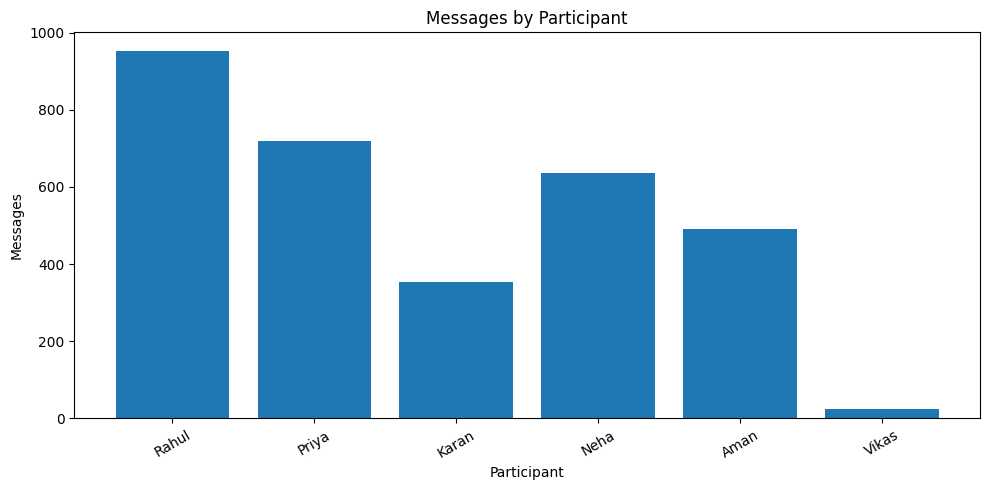

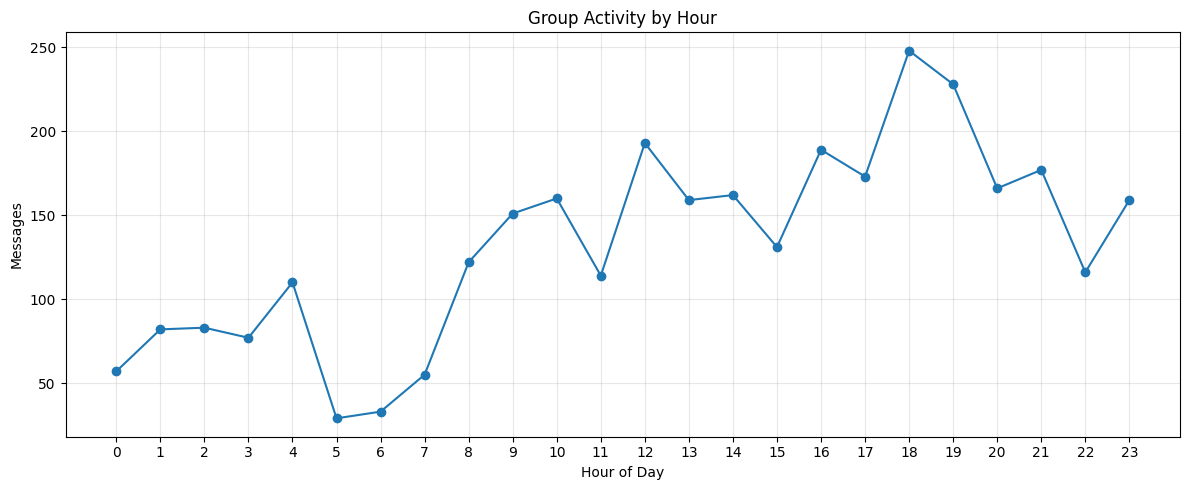

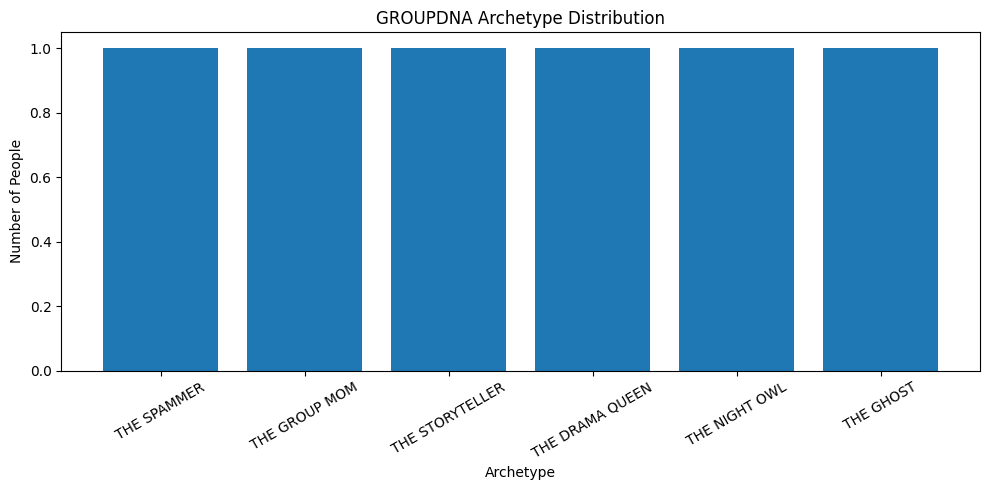

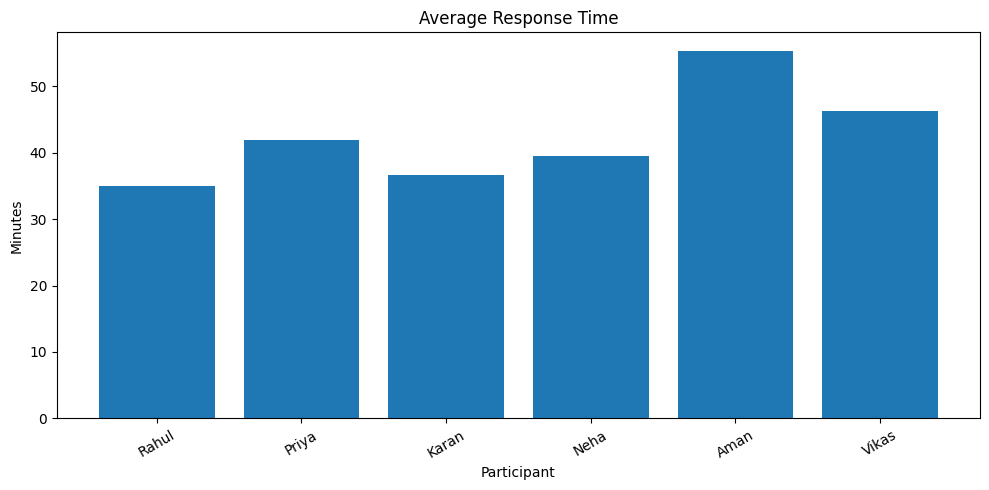

✅ Response time graph generated


In [ ]:
# ============================================================
# FEATURE 11 — GROUPDNA VISUAL DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

print("=" * 60)
print("                 GROUPDNA DASHBOARD")
print("=" * 60)

# ------------------------------------------------------------
# 1. MESSAGE COUNT BY PERSON
# ------------------------------------------------------------

message_counts = {
    person: sum(1 for m in messages if m["sender"] == person)
    for person in participants
}

plt.figure(figsize=(10, 5))
plt.bar(message_counts.keys(), message_counts.values())
plt.title("Messages by Participant")
plt.xlabel("Participant")
plt.ylabel("Messages")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. ACTIVITY BY HOUR
# ------------------------------------------------------------

hour_counts = Counter(
    m["timestamp"].hour
    for m in messages
)

hours = list(range(24))
hour_values = [hour_counts[h] for h in hours]

plt.figure(figsize=(12, 5))
plt.plot(hours, hour_values, marker="o")
plt.title("Group Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Messages")
plt.xticks(hours)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. ARCHETYPE DISTRIBUTION
# ------------------------------------------------------------

archetype_counts = Counter(final_archetypes.values())

plt.figure(figsize=(10, 5))
plt.bar(archetype_counts.keys(), archetype_counts.values())
plt.title("GROUPDNA Archetype Distribution")
plt.xlabel("Archetype")
plt.ylabel("Number of People")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. RESPONSE TIME
# ------------------------------------------------------------


response_people = []
response_times = []

for person in participants:

    if person in response_summary:

        response_people.append(person)

        response_times.append(
            response_summary[person]["average_response_minutes"]
        )


plt.figure(figsize=(10, 5))

plt.bar(
    response_people,
    response_times
)

plt.title("Average Response Time")
plt.xlabel("Participant")
plt.ylabel("Minutes")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print("✅ Response time graph generated")

                 GROUPDNA DASHBOARD

GROUP OVERVIEW
----------------------------------------
Participants       : 6
Total messages     : 3174
Chat start         : 2024-04-01 01:17:00
Chat end           : 2024-05-30 23:31:00
Busiest day        : 2024-05-04 (76 messages)
Busiest hour       : 18:00 (248 messages)

PARTICIPANT DNA
----------------------------------------
Rahul      |  953 msgs |  34.95 min response |   24.67h silence | THE SPAMMER
Priya      |  718 msgs |  41.99 min response |   15.78h silence | THE GROUP MOM
Karan      |  354 msgs |  36.62 min response |   20.70h silence | THE STORYTELLER
Neha       |  635 msgs |  39.45 min response |   28.37h silence | THE DRAMA QUEEN
Aman       |  490 msgs |  55.36 min response |   21.85h silence | THE NIGHT OWL
Vikas      |   24 msgs |  46.30 min response |  292.63h silence | THE GHOST


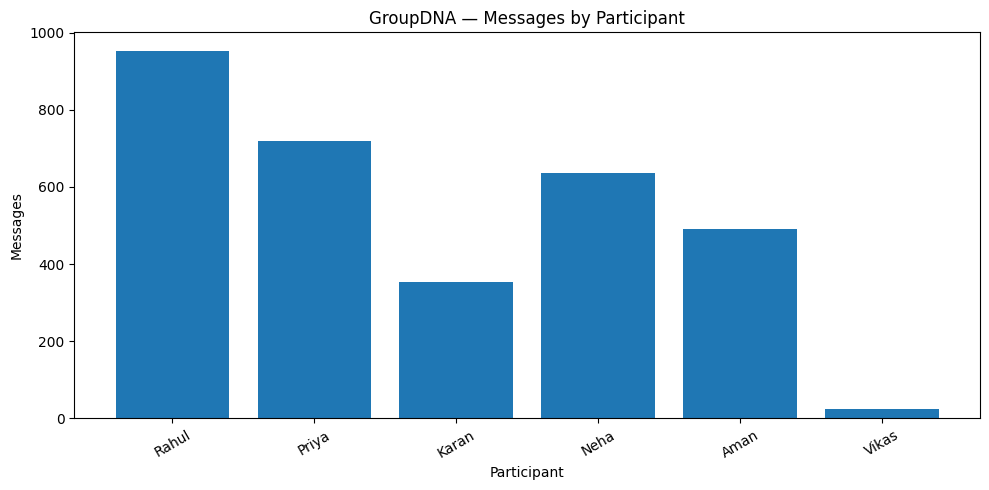

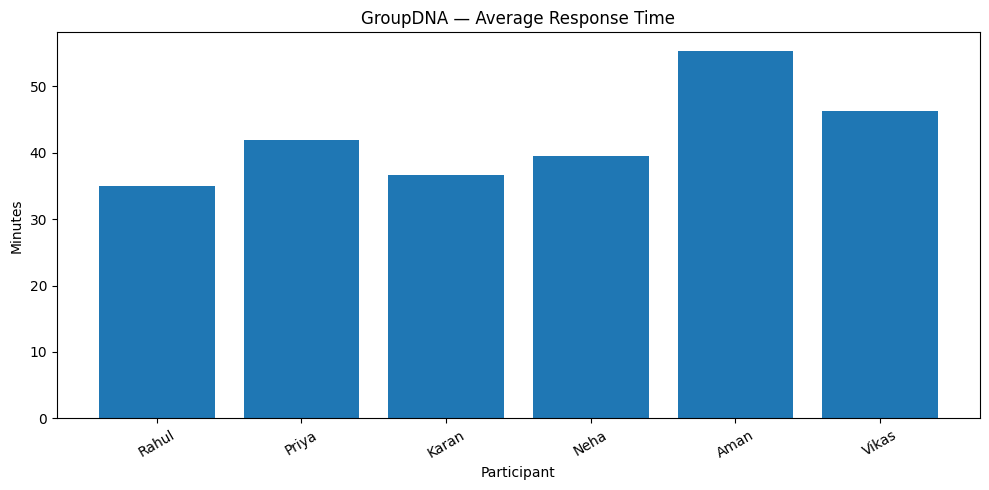

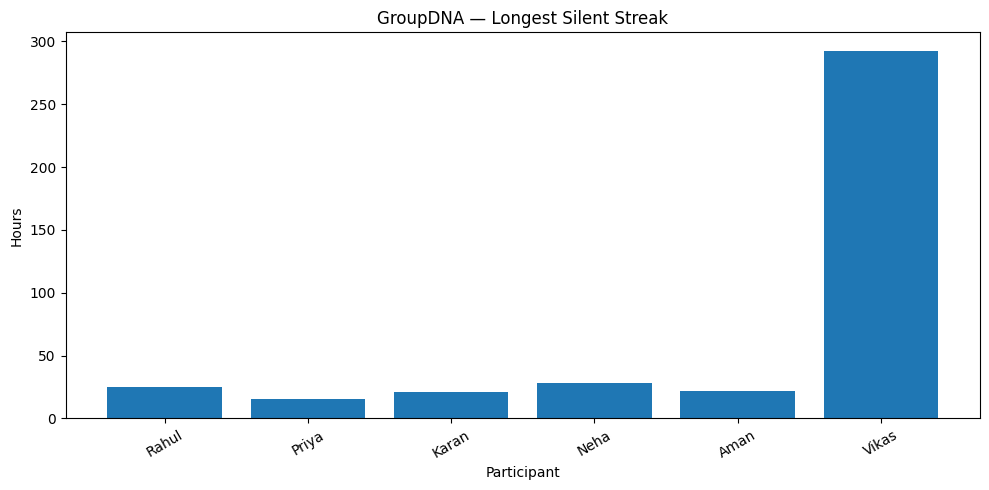



              GROUPDNA DASHBOARD READY


In [ ]:
# ============================================
# GROUPDNA — FINAL DASHBOARD
# ============================================

import matplotlib.pyplot as plt
from collections import Counter

print("=" * 60)
print("                 GROUPDNA DASHBOARD")
print("=" * 60)


# ============================================
# BASIC DATA
# ============================================

people = participants


# ============================================
# MESSAGE COUNTS
# ============================================

message_counts = []

for person in people:

    count = sum(
        1
        for msg in messages
        if msg["sender"] == person
    )

    message_counts.append(count)


# ============================================
# RESPONSE TIMES
# ============================================

response_times = []

for person in people:

    response_times.append(
        response_summary[person]["average_response_minutes"]
    )


# ============================================
# LONGEST SILENCE
# ============================================

silent_hours = []

for person in people:

    silent_hours.append(
        response_summary[person]["longest_silent_hours"]
    )


# ============================================
# ARCHETYPES
# ============================================

archetype_names = []

for person in people:

    archetype_names.append(
        final_archetypes[person]
    )


# ============================================
# GROUP OVERVIEW
# ============================================

print("\nGROUP OVERVIEW")
print("-" * 40)

print(f"Participants       : {len(people)}")
print(f"Total messages     : {len(messages)}")

print(
    f"Chat start         : {messages[0]['timestamp']}"
)

print(
    f"Chat end           : {messages[-1]['timestamp']}"
)


# ============================================
# BUSIEST DAY
# ============================================

day_counts = Counter(
    msg["timestamp"].strftime("%Y-%m-%d")
    for msg in messages
)

busiest_day, busiest_day_count = day_counts.most_common(1)[0]


# ============================================
# BUSIEST HOUR
# ============================================

hour_counts = Counter(
    msg["timestamp"].hour
    for msg in messages
)

busiest_hour, busiest_hour_count = hour_counts.most_common(1)[0]


print(
    f"Busiest day        : "
    f"{busiest_day} ({busiest_day_count} messages)"
)

print(
    f"Busiest hour       : "
    f"{busiest_hour}:00 ({busiest_hour_count} messages)"
)


# ============================================
# PARTICIPANT DNA TABLE
# ============================================

print("\nPARTICIPANT DNA")
print("-" * 40)

for i, person in enumerate(people):

    print(
        f"{person:<10} | "
        f"{message_counts[i]:>4} msgs | "
        f"{response_times[i]:>6.2f} min response | "
        f"{silent_hours[i]:>7.2f}h silence | "
        f"{archetype_names[i]}"
    )


# ============================================
# CHART 1 — MESSAGE COUNT
# ============================================

plt.figure(figsize=(10, 5))

plt.bar(
    people,
    message_counts
)

plt.title("GroupDNA — Messages by Participant")
plt.xlabel("Participant")
plt.ylabel("Messages")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================
# CHART 2 — RESPONSE TIME
# ============================================

plt.figure(figsize=(10, 5))

plt.bar(
    people,
    response_times
)

plt.title("GroupDNA — Average Response Time")
plt.xlabel("Participant")
plt.ylabel("Minutes")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================
# CHART 3 — SILENT STREAK
# ============================================

plt.figure(figsize=(10, 5))

plt.bar(
    people,
    silent_hours
)

plt.title("GroupDNA — Longest Silent Streak")
plt.xlabel("Participant")
plt.ylabel("Hours")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================
# COMPLETE
# ============================================

print("\n")
print("=" * 60)
print("              GROUPDNA DASHBOARD READY")
print("=" * 60)

In [ ]:
# ============================================================
# GROUPDNA — FINAL RESULT SCREEN
# ============================================================

from collections import Counter

# -----------------------------
# MESSAGE COUNTS
# -----------------------------

date_counts = Counter(
    msg["timestamp"].date()
    for msg in messages
)

hour_counts = Counter(
    msg["timestamp"].hour
    for msg in messages
)

# Correct busiest day
busiest_day = max(date_counts.items(), key=lambda x: x[1])

# Correct busiest hour
busiest_hour = max(hour_counts.items(), key=lambda x: x[1])


# ============================================================
# FINAL SCREEN
# ============================================================

print("=" * 70)
print("                    GROUPDNA")
print("              CHAT PERSONALITY ANALYZER")
print("=" * 70)

print("\n📊 GROUP")
print("-" * 70)

print(f"Participants : {len(participants)}")
print(f"Messages     : {len(messages)}")
print(
    f"Period       : "
    f"{messages[0]['timestamp'].date()} → "
    f"{messages[-1]['timestamp'].date()}"
)

print(
    f"Busiest day  : "
    f"{busiest_day[0]} ({busiest_day[1]} messages)"
)

print(
    f"Busiest hour : "
    f"{busiest_hour[0]:02d}:00 ({busiest_hour[1]} messages)"
)


# ============================================================
# PERSONALITIES
# ============================================================

print("\n🧬 GROUPDNA PERSONALITIES")
print("-" * 70)

for person in participants:

    archetype = final_archetypes.get(person, "UNCLASSIFIED")

    print(f"{person:<12} → {archetype}")


# ============================================================
# EVIDENCE
# ============================================================

print("\n🔍 ARCHETYPE EVIDENCE")
print("-" * 70)

for person in participants:

    archetype = final_archetypes.get(person, "")

    if archetype == "THE SPAMMER":
        evidence = f"{archetype_scores[person]['spammer']:.2f} average messages per burst"

    elif archetype == "THE GROUP MOM":
        evidence = f"{archetype_scores[person]['group_mom']:.0f} caring keyword hits"

    elif archetype == "THE STORYTELLER":
        evidence = f"{archetype_scores[person]['storyteller']:.2f} average words/message"

    elif archetype == "THE DRAMA QUEEN":
        evidence = f"{archetype_scores[person]['drama_queen']:.2f}% dramatic messages"

    elif archetype == "THE NIGHT OWL":
        evidence = f"{archetype_scores[person]['night_owl']:.2f}% night messages"

    elif archetype == "THE GHOST":
        evidence = f"{archetype_scores[person]['ghost']:.2f}% silent days"

    else:
        evidence = "No evidence available"

    print(f"{person:<12} → {evidence}")


print("\n" + "=" * 70)
print("                 GROUPDNA READY 🚀")
print("=" * 70)

                    GROUPDNA
              CHAT PERSONALITY ANALYZER

📊 GROUP
----------------------------------------------------------------------
Participants : 6
Messages     : 3174
Period       : 2024-04-01 → 2024-05-30
Busiest day  : 2024-05-04 (76 messages)
Busiest hour : 18:00 (248 messages)

🧬 GROUPDNA PERSONALITIES
----------------------------------------------------------------------
Rahul        → THE SPAMMER
Priya        → THE GROUP MOM
Karan        → THE STORYTELLER
Neha         → THE DRAMA QUEEN
Aman         → THE NIGHT OWL
Vikas        → THE GHOST

🔍 ARCHETYPE EVIDENCE
----------------------------------------------------------------------
Rahul        → 4.52 average messages per burst
Priya        → 576 caring keyword hits
Karan        → 57.05 average words/message
Neha         → 62.20% dramatic messages
Aman         → 79.80% night messages
Vikas        → 73.33% silent days

                 GROUPDNA READY 🚀


In [ ]:
# FINAL CHECK

import os

print("GROUPDNA FINAL CHECK")
print("=" * 40)

print("Messages analyzed :", len(messages))
print("Participants      :", len(participants))
print("JSON report       :", os.path.exists("groupdna_report.json"))

print("\nArchetypes:")
for person in participants:
    print(f"{person} → {final_archetypes[person]}")

print("\n✅ PROJECT COMPLETE")

GROUPDNA FINAL CHECK
Messages analyzed : 3174
Participants      : 6
JSON report       : True

Archetypes:
Rahul → THE SPAMMER
Priya → THE GROUP MOM
Karan → THE STORYTELLER
Neha → THE DRAMA QUEEN
Aman → THE NIGHT OWL
Vikas → THE GHOST

✅ PROJECT COMPLETE


In [1]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [2]:
from google.colab import files

files.download("groupdna_report.json")

FileNotFoundError: Cannot find file: groupdna_report.json